In [1]:
# Importing libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# Reading the dataset 
data = pd.read_csv("C:/Users/saila/Downloads/Housing (1).csv")

In [3]:
# Looking at the structure of the raw dataset
# The target variable for our desired model is price, and now we must decide which features to keep and drop
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
# Studying and verifying the data types of the columns of the raw dataset
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [5]:
# Explains statistical details of the raw dataset
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
# Creates a DataFrame from the raw dataset for us to clean and manipulate the data 
df = pd.DataFrame(data=data)
print(df)

        price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       no   

    hotwaterheating aircond

In [7]:
# Checking for number of missing values per column
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
# Checking for total number of duplicate values
df.duplicated().sum()

np.int64(0)

In [9]:
# Implementing binary encoding to convert string values ('yes' or 'no') to integer
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for col in binary_cols:
    df[col] = df[col].map({
        'yes':1,
        'no':0
    })

# Implementing one-hot encoding for multi-class categories (multiple string options) to create dummy columns representing each option
# Each dummy column is a binary value (1 or 0) representing whether the value of the multi-class category 
df = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    dtype=int
)
print(df)

        price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0    13300000  7420         4          2        3         1          0   
1    12250000  8960         4          4        4         1          0   
2    12250000  9960         3          2        2         1          0   
3    12215000  7500         4          2        2         1          0   
4    11410000  7420         4          1        2         1          1   
..        ...   ...       ...        ...      ...       ...        ...   
540   1820000  3000         2          1        1         1          0   
541   1767150  2400         3          1        1         0          0   
542   1750000  3620         2          1        1         1          0   
543   1750000  2910         3          1        1         0          0   
544   1750000  3850         3          1        2         1          0   

     basement  hotwaterheating  airconditioning  parking  prefarea  \
0           0                0           

In [10]:
# Checking the data types of different normalized categories and verifying if all are integer
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_furnished       545 non-null    int64
 13  f

       price   area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0   13300000   7420         4          2        3         1          0   
1   12250000   8960         4          4        4         1          0   
2   12250000   9960         3          2        2         1          0   
3   12215000   7500         4          2        2         1          0   
4   11410000   7420         4          1        2         1          1   
5   10850000   7500         3          3        1         1          0   
6   10150000   8580         4          3        4         1          0   
7   10150000  16200         5          3        2         1          0   
8    9870000   8100         4          1        2         1          1   
9    9800000   5750         3          2        4         1          1   
10   9800000  13200         3          1        2         1          0   
11   9681000   6000         4          3        2         1          1   
12   9310000   6550         4         

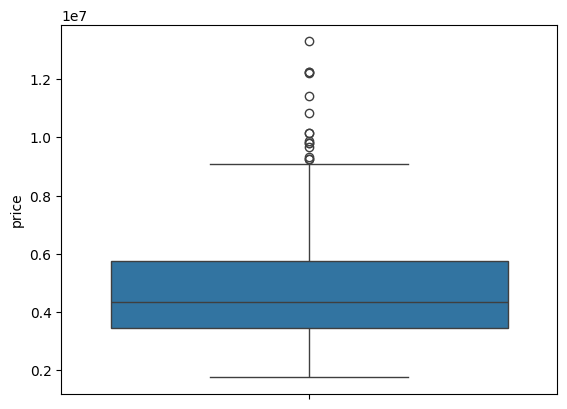

In [11]:
# Checking for price outliers to see if they are valid entries or data entry mistakes
# The outliers here are high-end luxury properties
sns.boxplot(df['price'])
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['price'] < lower) | (df['price'] > upper)]
print(outliers)

        price   area  bedrooms  bathrooms  stories  mainroad  guestroom  \
7    10150000  16200         5          3        2         1          0   
10    9800000  13200         3          1        2         1          0   
56    7343000  11440         4          1        2         1          0   
64    7000000  11175         3          1        1         1          0   
66    6930000  13200         2          1        1         1          0   
69    6790000  12090         4          2        2         1          0   
125   5943000  15600         3          1        1         1          0   
129   5873000  11460         3          1        3         1          0   
186   5110000  11410         2          1        2         1          0   
191   5040000  10700         3          1        2         1          1   
211   4900000  12900         3          1        1         1          0   
403   3500000  12944         3          1        1         1          0   

     basement  hotwaterh

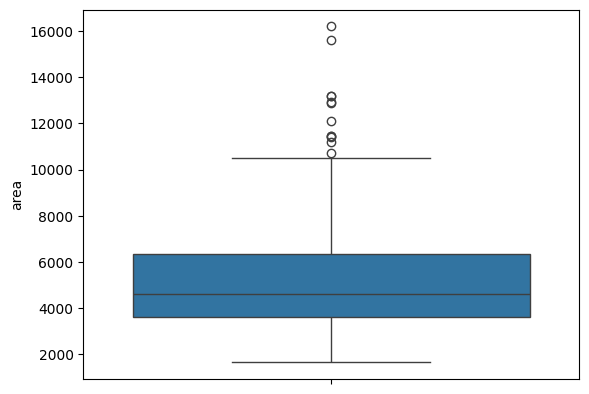

In [12]:
# Checking for area outliers to see if they are valid entries or data entry mistakes
# The outliers here are high-end properties with larger but feasible areas
sns.boxplot(df['area'])
Q1 = df['area'].quantile(0.25)
Q3 = df['area'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['area'] < lower) | (df['area'] > upper)]
print(outliers)

        price   area  bedrooms  bathrooms  stories  mainroad  guestroom  \
7    10150000  16200         5          3        2         1          0   
28    8400000   7950         5          2        2         1          0   
34    8120000   6840         5          1        2         1          1   
89    6440000   8580         5          3        2         1          0   
112   6083000   4300         6          2        2         1          0   
143   5600000   4800         5          2        3         0          0   
152   5565000   5400         5          1        2         1          1   
271   4340000   1905         5          1        2         0          0   
340   3850000   5300         5          2        2         1          0   
356   3773000   2520         5          2        1         0          0   
395   3500000   3600         6          1        2         1          0   
536   1960000   3420         5          1        2         0          0   

     basement  hotwaterh

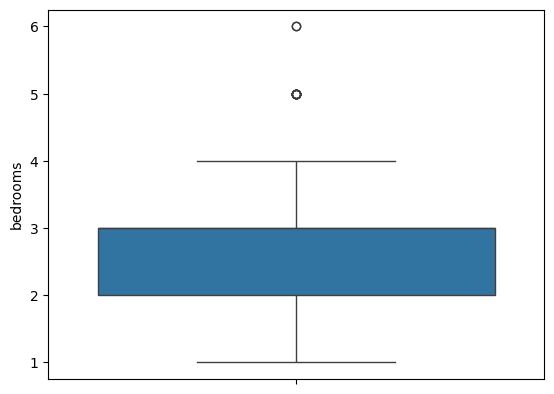

In [13]:
# Checking for bedroom outliers to see if they are valid entries or data entry mistakes
# The outliers here are high-end properties with a large number of rooms
sns.boxplot(df['bedrooms'])
Q1 = df['bedrooms'].quantile(0.25)
Q3 = df['bedrooms'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['bedrooms'] < lower) | (df['bedrooms'] > upper)]
print(outliers)

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
1  12250000  8960         4          4        4         1          0   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
1         0                0                1        3         0   

   furnishingstatus_furnished  furnishingstatus_semi-furnished  \
1                           1                                0   

   furnishingstatus_unfurnished  
1                             0  


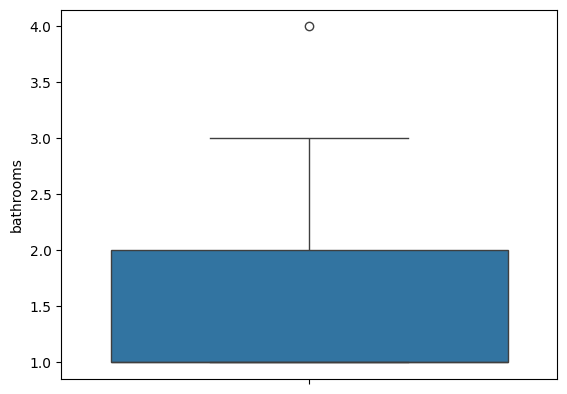

In [14]:
# Checking for bathroom outliers to see if they are valid entries or data entry mistakes
# The outliers here are high-end properties with a large number of rooms
sns.boxplot(df['bathrooms'])
Q1 = df['bathrooms'].quantile(0.25)
Q3 = df['bathrooms'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['bathrooms'] < lower) | (df['bathrooms'] > upper)]
print(outliers)

        price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
1    12250000  8960         4          4        4         1          0   
6    10150000  8580         4          3        4         1          0   
9     9800000  5750         3          2        4         1          1   
17    8960000  8500         3          2        4         1          0   
26    8463000  6000         3          2        4         1          1   
30    8400000  7475         3          2        4         1          0   
31    8400000  7000         3          1        4         1          0   
35    8080940  7000         3          2        4         1          0   
37    7980000  9000         4          2        4         1          0   
38    7962500  6000         3          1        4         1          1   
39    7910000  6000         4          2        4         1          0   
41    7840000  6360         3          2        4         1          0   
42    7700000  6480         3         

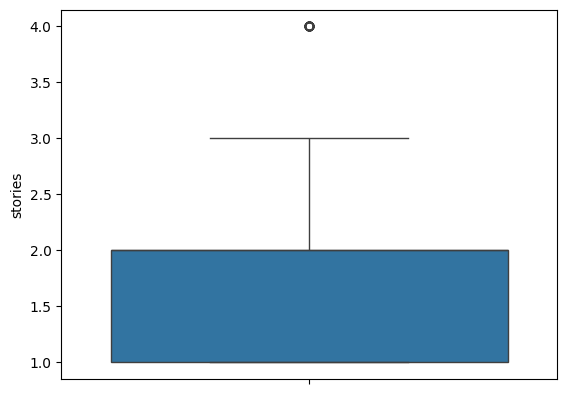

In [15]:
# Checking for storey outliers to see if they are valid entries or data entry mistakes
# The outliers here are high-end properties with a lot of floors
sns.boxplot(df['stories'])
Q1 = df['stories'].quantile(0.25)
Q3 = df['stories'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['stories'] < lower) | (df['stories'] > upper)]
print(outliers)

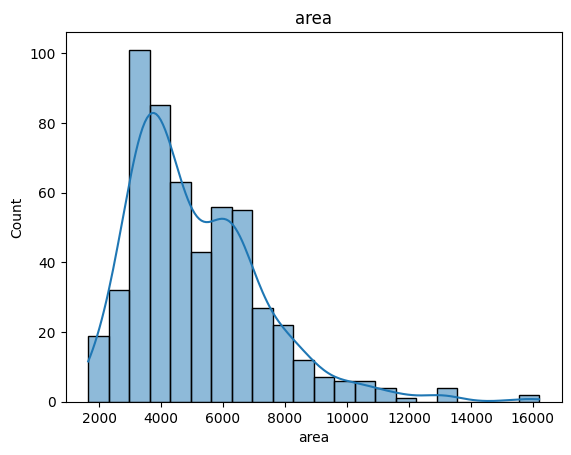

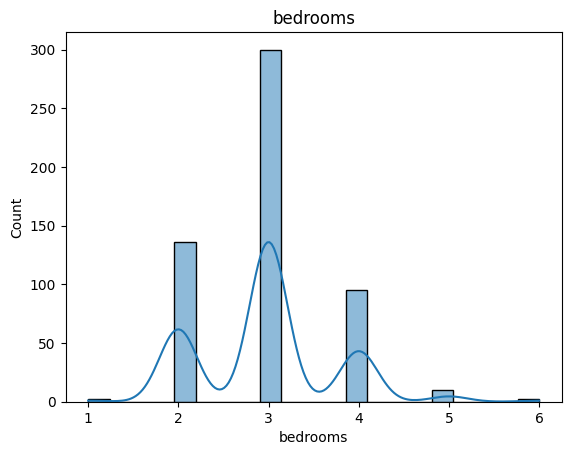

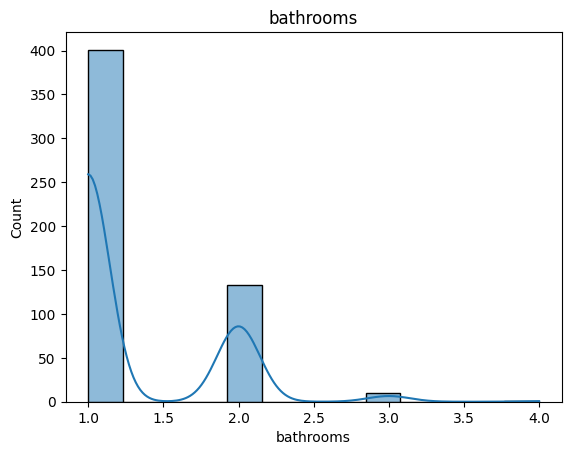

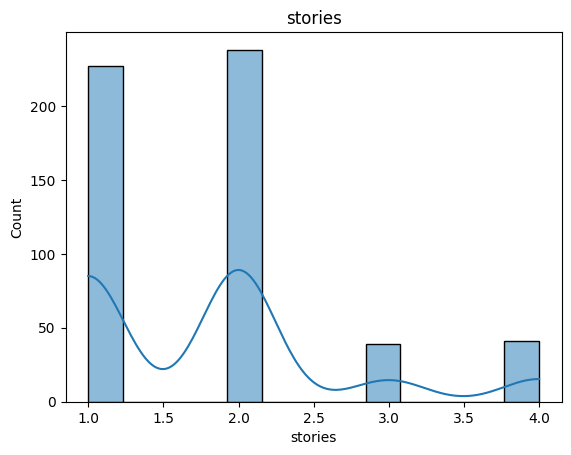

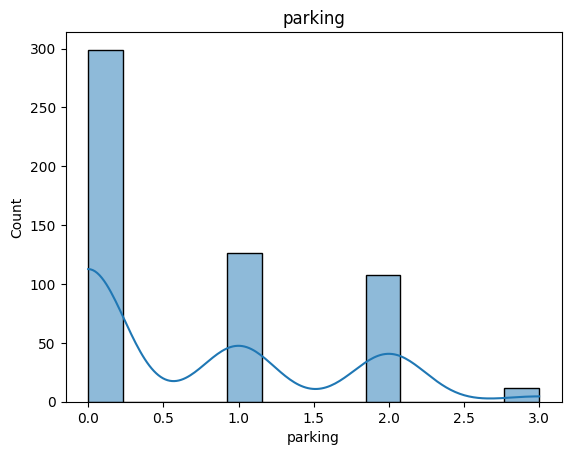

In [16]:
# Plotting the histplot for the non-binary categories to observe their skewness
# Area is skewed right, showing that most of the properties have a median area of around 3500 - 4000 units, with several high-end luxury properties
# having larger area, number of rooms, etc
# bedrooms, bathrooms, stories, and parking exhibit moderate variation and contain a small number of high-value observations
num_cols = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'parking'
]
for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

1.2122388370279802


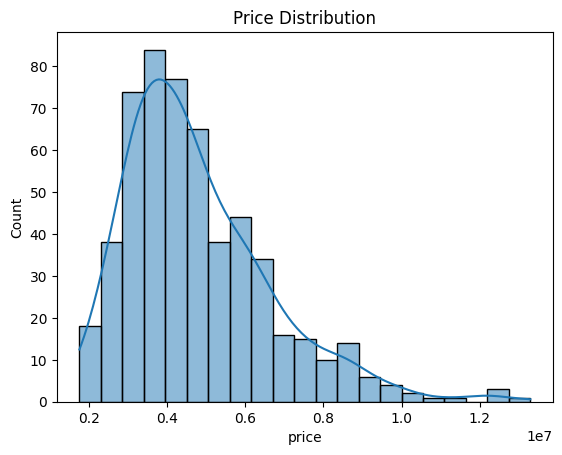

In [17]:
# Price is skewed right similar to the area category, with most properties costing 0.3e7 - 0.4e7 units, while several high-end luxury properties
# cost more 
print(df['price'].skew())
sns.histplot(df['price'], kde=True)
plt.title('Price Distribution')
plt.show()

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
furnishingstatus_furnished         0.229350
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


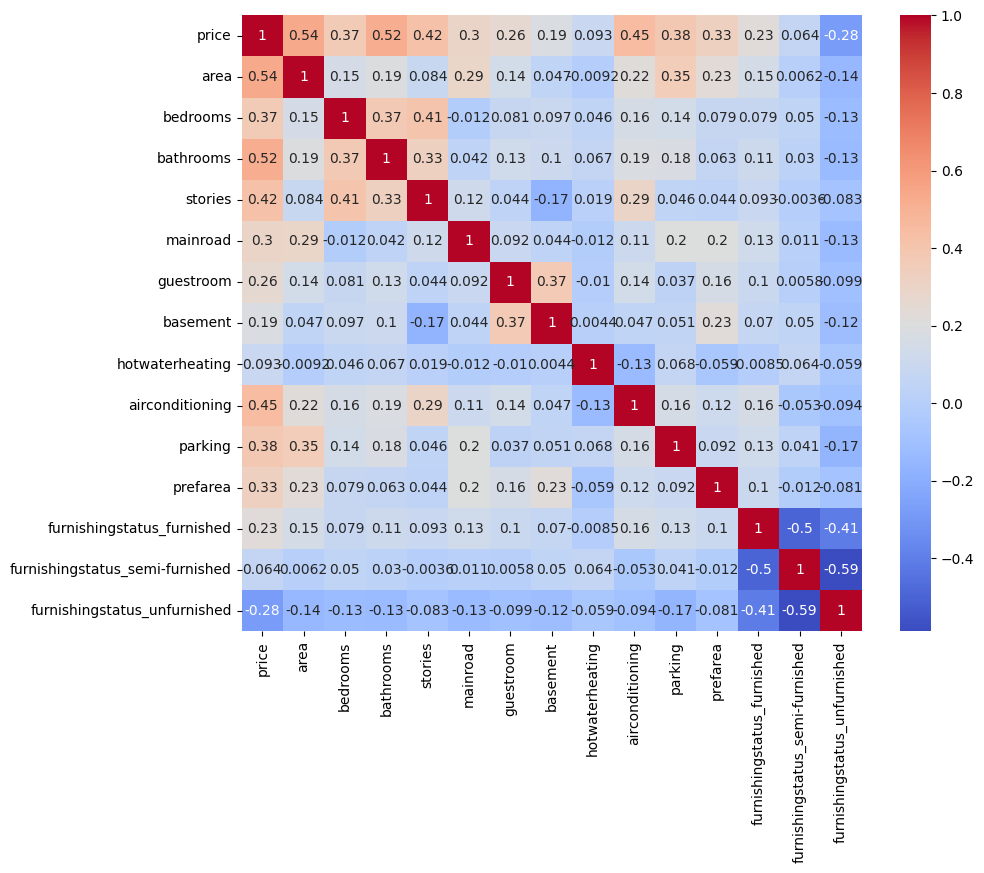

In [18]:
# Checking for multicollinearity between categories with the help of a correlation heatmap
# Both hotwaterheating and furnishingstatus_semi-furnished categories exhibit the weakest linear relationship with price, as they are closest to zero
corr = df.corr(numeric_only=True)
print(corr['price'].sort_values(ascending=False))
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

In [19]:
# Checking for multicollinearity between categories with the help of the Variance Inflation Factor (VIF)
# furnishingstatus_furnished, furnishingstatus_semi-furnished, furnishingstatus_unfurnished have the highest VIF, indicating that they are highly
# dependent on other categories resulting in multicollinearity
X = df.drop('price', axis=1)
vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values,i)
    for i in range(X.shape[1])
]
print(vif)

                            Feature        VIF
0                              area   1.325250
1                          bedrooms   1.369477
2                         bathrooms   1.286621
3                           stories   1.478055
4                          mainroad   1.172728
5                         guestroom   1.212838
6                          basement   1.323050
7                   hotwaterheating   1.041506
8                   airconditioning   1.211840
9                           parking   1.212837
10                         prefarea   1.149196
11       furnishingstatus_furnished   8.575840
12  furnishingstatus_semi-furnished  12.404306
13     furnishingstatus_unfurnished   8.826219


In [20]:
#We solve this by dropping furnishingstatus_semi-furnished, as it is linearly dependent on furnished and unfurnished categories and it has the 
# lowest correlation coefficient with price 
df = df.drop('furnishingstatus_semi-furnished',axis=1)

In [21]:
# We are checking the VIF for the categories after dropping the semi-furnished column, and the VIF of both furnished and unfurnished columns is small
# Additionally, we can observe that the VIF of area, bedrooms, bathrooms, and stories are higher, but this is to be expected as larger houses naturally
# tend to have a larger number of rooms and stories
X = df.drop('price', axis=1)
vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values,i)
    for i in range(X.shape[1])
]
print(vif)

                         Feature        VIF
0                           area   8.280287
1                       bedrooms  15.668590
2                      bathrooms   9.413944
3                        stories   7.884697
4                       mainroad   6.853701
5                      guestroom   1.470778
6                       basement   2.017734
7                hotwaterheating   1.091392
8                airconditioning   1.757763
9                        parking   1.979708
10                      prefarea   1.489285
11    furnishingstatus_furnished   1.650160
12  furnishingstatus_unfurnished   1.664680


In [22]:
# Download the cleaned dataset
df.to_csv('housing_cleaned.csv', index=False)